In [1]:
%pip install pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 47.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 50.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 50.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

file_id = '10FwLy34tDMePO75ldYlM4RDoATsLkPfh'   # new file
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

loan_df = pd.read_csv(url)
loan_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 391166 entries, 0 to 391165
Data columns (total 59 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   391166 non-null  int64  
 1   term                        391166 non-null  int64  
 2   int_rate                    391166 non-null  float64
 3   installment                 391166 non-null  float64
 4   sub_grade                   391166 non-null  str    
 5   emp_length                  391166 non-null  float64
 6   home_ownership              391166 non-null  str    
 7   annual_inc                  391166 non-null  float64
 8   verification_status         391166 non-null  str    
 9   purpose                     391166 non-null  str    
 10  dti                         391166 non-null  float64
 11  delinq_2yrs                 391166 non-null  float64
 12  inq_last_6mths              391166 non-null  float64
 13  open_acc                 

In [3]:
import numpy as np

# Copy dataset to avoid overwriting original
df_policy = loan_df.copy()

# Replace 0s to avoid division errors
df_policy["annual_inc"] = df_policy["annual_inc"].replace(0, np.nan)
df_policy["loan_amnt"] = df_policy["loan_amnt"].replace(0, np.nan)
df_policy["installment"] = df_policy["installment"].replace(0, np.nan)

# -----------------------------
#  Financial Ratios
# -----------------------------

# Income relative to loan size -> higher = more ability to repay
df_policy["income_to_loan_ratio"] = df_policy["annual_inc"] / df_policy["loan_amnt"]

# Loan size relative to income -> higher = more risk / burden
df_policy["loan_to_income_ratio"] = df_policy["loan_amnt"] / df_policy["annual_inc"]

# Annual payment burden relative to income -> measures affordability
df_policy["installment_to_income_ratio"] = (df_policy["installment"] * 12) / df_policy["annual_inc"]

# Monthly income vs payment -> ability to comfortably make payments
df_policy["income_to_installment_ratio"] = (df_policy["annual_inc"] / 12) / df_policy["installment"]

# Existing revolving debt burden -> captures current financial strain
df_policy["revol_bal_to_income_ratio"] = df_policy["revol_bal"] / df_policy["annual_inc"]

# Available credit vs total credit -> higher = more unused capacity
df_policy["available_credit_ratio"] = df_policy["bc_open_to_buy"] / df_policy["total_rev_hi_lim"]

# Remaining utilization capacity -> higher = lower current credit usage
df_policy["all_util_headroom"] = 100 - df_policy["all_util"]

# -----------------------------
# Clean up infinite values
# -----------------------------
df_policy.replace([np.inf, -np.inf], np.nan, inplace=True)

# Quick check
ratio_cols = [
    "income_to_loan_ratio",
    "loan_to_income_ratio",
    "installment_to_income_ratio",
    "income_to_installment_ratio",
    "revol_bal_to_income_ratio",
    "available_credit_ratio",
    "all_util_headroom"
]

df_policy[ratio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
income_to_loan_ratio,391166.0,7.220893,7.643163,0.001219,3.437500,5.000000,8.000000,489.795918
loan_to_income_ratio,391166.0,0.218623,1.381245,0.002042,0.125000,0.200000,0.290909,820.512821
installment_to_income_ratio,391166.0,0.080646,0.479542,0.000814,0.046336,0.072276,0.105364,282.569231
income_to_installment_ratio,391166.0,19.112476,19.195519,0.003539,9.490899,13.835851,21.581322,1228.803146
revol_bal_to_income_ratio,391166.0,0.228782,1.289628,0.000000,0.098340,0.179552,0.295727,793.641026
available_credit_ratio,366772.0,0.274964,0.229596,0.000000,0.082452,0.218924,0.420906,1.000000
all_util_headroom,149582.0,41.784372,20.965805,-98.000000,27.000000,40.000000,56.000000,100.000000


In [4]:
def calculate_loan_revenue(loan_amnt, int_rate, term):
    """
    Calculate loan revenue metrics.
    
    Parameters
    ----------
    loan_amnt : float — principal in dollars
    int_rate  : float — annual interest rate as percentage (e.g. 13.5)
    term      : int   — term in months (36 or 60)
    
    Returns
    -------
    dict: 
    total_interest -> gross interest revenue earned over the loan lifetime (total repaid minus principal).
    yield_on_principal -> total interest as a fraction of loan amount, enables profitability comparison across loan sizes.
    
    """
    r = int_rate / 100 / 12

    if r == 0:
        installment = loan_amnt / term
    else:
        installment = loan_amnt * r * (1 + r)**term / ((1 + r)**term - 1)

    total_repaid = installment * term
    total_interest = total_repaid - loan_amnt

    return {
        "total_interest":     round(total_interest, 2),
        "yield_on_principal": round(total_interest / loan_amnt, 4),
    }

# Apply to dataframe
revenue_cols = loan_df.apply(
    lambda row: calculate_loan_revenue(row["loan_amnt"], row["int_rate"], row["term"]),
    axis=1,
    result_type="expand"
)
df_policy = pd.concat([df_policy, revenue_cols], axis=1)

In [5]:
df_policy['total_interest']

0           702.40
1          2210.11
2          4236.58
3          1793.76
4         11254.25
            ...   
391161     5413.60
391162     1136.55
391163     2099.64
391164    18680.57
391165      337.46
Name: total_interest, Length: 391166, dtype: float64

### Loss Given Default (LGD) assumption or calculation

In [6]:
import pandas as pd

# load full dataset after cleaning
file_id = '1ewIyvaTB1T_BVNM5CYNTXrIpPv9kJjK3'
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

# load data
full_loan_df = pd.read_csv(url)
full_loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2255820 entries, 0 to 2255819
Data columns (total 61 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   term                        int64  
 2   int_rate                    float64
 3   installment                 float64
 4   sub_grade                   str    
 5   emp_title                   str    
 6   emp_length                  float64
 7   home_ownership              str    
 8   annual_inc                  float64
 9   verification_status         str    
 10  loan_status                 str    
 11  purpose                     str    
 12  addr_state                  str    
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  inq_last_6mths              float64
 16  open_acc                    float64
 17  pub_rec                     float64
 18  revol_bal                   int64  
 19  revol_util                  floa

In [7]:
# separate default data
full_loan_df = full_loan_df[full_loan_df['loan_status'].isin(['Fully Paid','Charged Off', 'Default', 'Does not meet the credit policy. Status:Fully Paid',
                'Does not meet the credit policy. Status:Charged Off'])]

# binary categorize for loan_status
full_loan_df['loan_status'] = full_loan_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid':0,
    'Does not meet the credit policy. Status:Charged Off':1
})


default_df = full_loan_df[full_loan_df['loan_status']==1].copy()

In [8]:
default_df.info()

<class 'pandas.DataFrame'>
Index: 261881 entries, 5033 to 2255807
Data columns (total 61 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   261881 non-null  int64  
 1   term                        261881 non-null  int64  
 2   int_rate                    261881 non-null  float64
 3   installment                 261881 non-null  float64
 4   sub_grade                   261881 non-null  str    
 5   emp_title                   261881 non-null  str    
 6   emp_length                  261881 non-null  float64
 7   home_ownership              261881 non-null  str    
 8   annual_inc                  261881 non-null  float64
 9   verification_status         261881 non-null  str    
 10  loan_status                 261881 non-null  int64  
 11  purpose                     261881 non-null  str    
 12  addr_state                  261881 non-null  str    
 13  dti                       

In [9]:
# calculate total_recovery
default_df['total_recovered'] = (
    default_df['total_rec_prncp']
    + default_df['recoveries']
    - default_df['collection_recovery_fee']
)

In [10]:
# compute recovery rate
default_df['recovery_rate'] = default_df['total_recovered']/default_df['loan_amnt']
default_df['recovery_rate'] = default_df['recovery_rate'].clip(0,1)

# compute LGD
default_df['lgd'] = 1 - default_df['recovery_rate']

print(f"LGD mean: {default_df['lgd'].mean()}")
print(f"LGD median: {default_df['lgd'].median()}")

LGD mean: 0.6373195377363204
LGD median: 0.6791839175250722


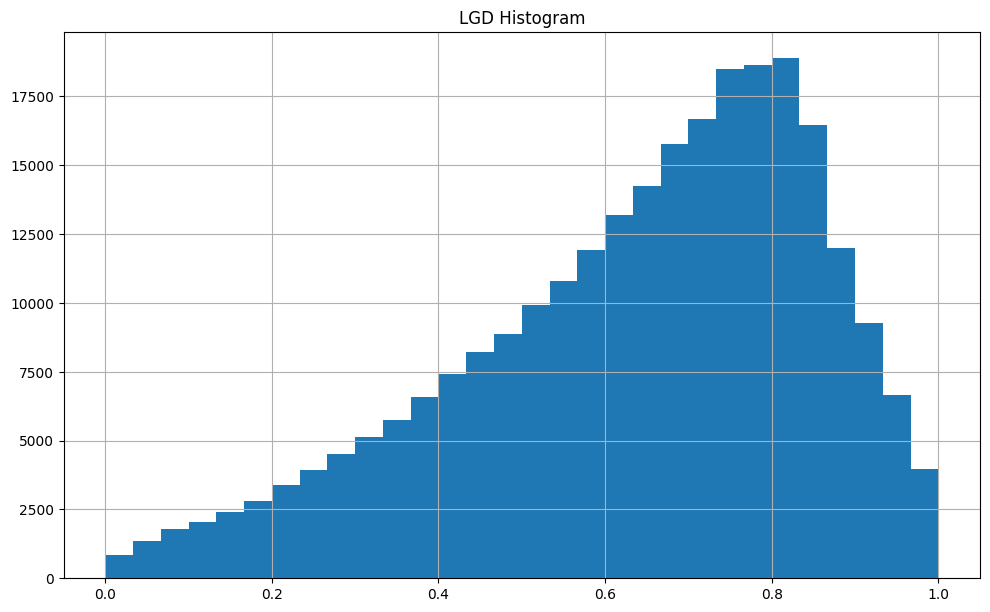

In [11]:
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
default_df['lgd'].hist(figsize=(10, 6), bins=30)
plt.tight_layout()
plt.title('LGD Histogram')
plt.show()

Inspecting LGD grouped by grade

In [12]:
lgd_by_grade = default_df.groupby('sub_grade')['lgd'].agg(['mean', 'median', 'count', 'std'])
lgd_by_grade = lgd_by_grade.sort_index()  # ensure A, B, C, D, E, F, G order

print(lgd_by_grade)

grades = lgd_by_grade.index.tolist()
means = lgd_by_grade['mean'].values
medians = lgd_by_grade['median'].values
counts = lgd_by_grade['count'].values
stds = lgd_by_grade['std'].values

               mean    median  count       std
sub_grade                                     
A1         0.515539  0.519892   1360  0.238879
A2         0.532071  0.548389   1678  0.243980
A3         0.539449  0.554675   2022  0.239253
A4         0.535633  0.550776   3473  0.240319
A5         0.536775  0.557443   5227  0.235512
B1         0.559541  0.581114   7200  0.229868
B2         0.555538  0.571861   8155  0.227426
B3         0.568080  0.594664  10354  0.225475
B4         0.574821  0.600562  12004  0.218934
B5         0.588532  0.619748  13381  0.218661
C1         0.602504  0.629240  15757  0.213014
C2         0.610229  0.647100  15993  0.212230
C3         0.621307  0.657719  16463  0.212110
C4         0.637276  0.676691  18003  0.205970
C5         0.648088  0.690211  17059  0.204916
D1         0.644172  0.680174  13959  0.205960
D2         0.655482  0.698548  12908  0.203197
D3         0.664160  0.708023  11675  0.203722
D4         0.670941  0.710493  11245  0.199302
D5         0.

In [13]:
# Create lookup of mean LGD by sub_grade
lgd_lookup = lgd_by_grade["mean"].to_dict()

# Save overall mean LGD as fallback
overall_lgd_mean = default_df["lgd"].mean()

print("Overall mean LGD:", round(overall_lgd_mean, 4))

Overall mean LGD: 0.6373


In [14]:
# Map mean LGD by sub_grade into the policy dataset
df_policy["expected_lgd"] = df_policy["sub_grade"].map(lgd_lookup)

# Fill any missing sub_grade LGD values with overall mean LGD
df_policy["expected_lgd"] = df_policy["expected_lgd"].fillna(overall_lgd_mean)

df_policy[["sub_grade", "expected_lgd"]].head()

,sub_grade,expected_lgd
0,D2,0.655482
1,C3,0.621307
2,B4,0.574821
3,D5,0.683216
4,E3,0.701859


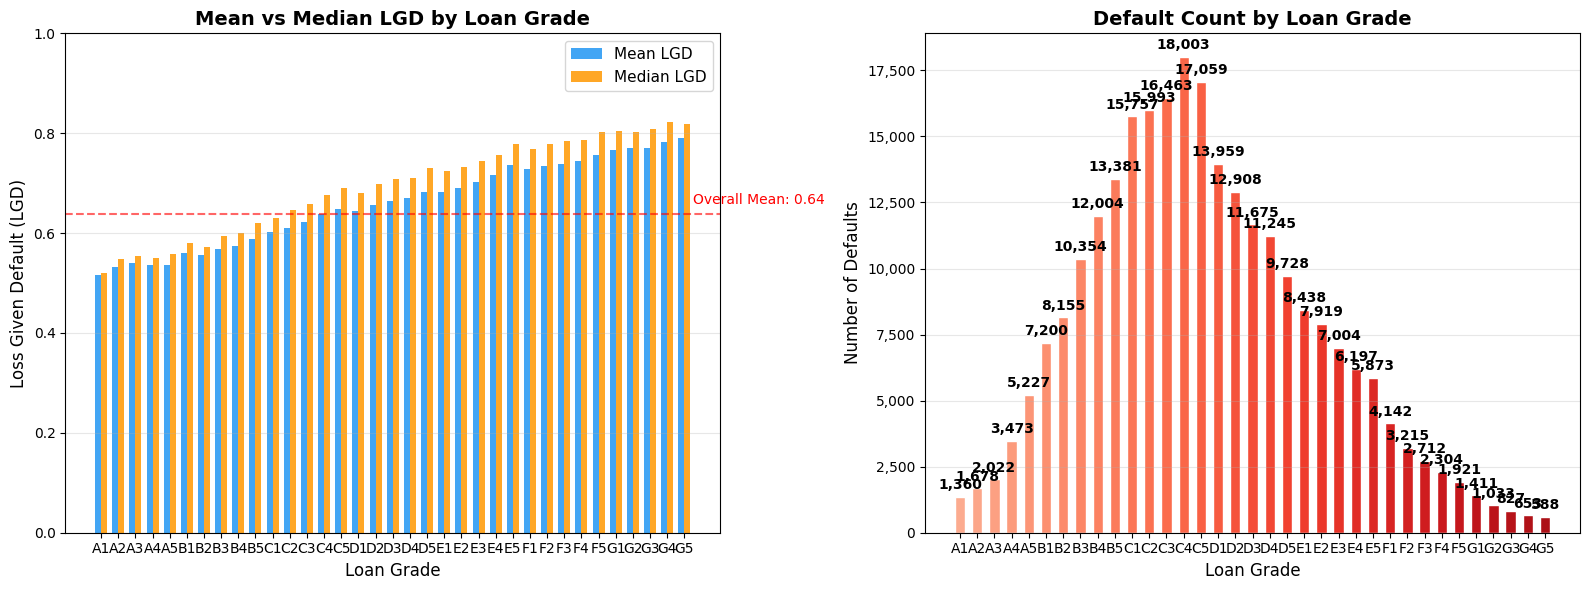

In [15]:
import numpy as np
x = np.arange(len(grades))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left plot: Mean vs Median ---
bars1 = axes[0].bar(x - width/2, means, width, label='Mean LGD', color='#2196F3', alpha=0.85)
bars2 = axes[0].bar(x + width/2, medians, width, label='Median LGD', color='#FF9800', alpha=0.85)

# Add value labels on bars
'''for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)'''

axes[0].set_xlabel('Loan Grade', fontsize=12)
axes[0].set_ylabel('Loss Given Default (LGD)', fontsize=12)
axes[0].set_title('Mean vs Median LGD by Loan Grade', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(grades)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=default_df['lgd'].mean(), color='red', linestyle='--', alpha=0.6, label='Overall Mean')
axes[0].text(len(grades) - 0.5, default_df['lgd'].mean() + 0.02,
             f"Overall Mean: {default_df['lgd'].mean():.2f}", color='red', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# --- Right plot: Count of defaults by grade ---
colors = plt.cm.Reds(np.linspace(0.3, 0.85, len(grades)))
bars3 = axes[1].bar(x, counts, width=0.6, color=colors, edgecolor='white')

for bar, count in zip(bars3, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                 f'{int(count):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_xlabel('Loan Grade', fontsize=12)
axes[1].set_ylabel('Number of Defaults', fontsize=12)
axes[1].set_title('Default Count by Loan Grade', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(grades)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, pos: f'{int(val):,}'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lgd_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_5915/144187362.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(grade_data, labels=grades, patch_artist=True, showmeans=True,


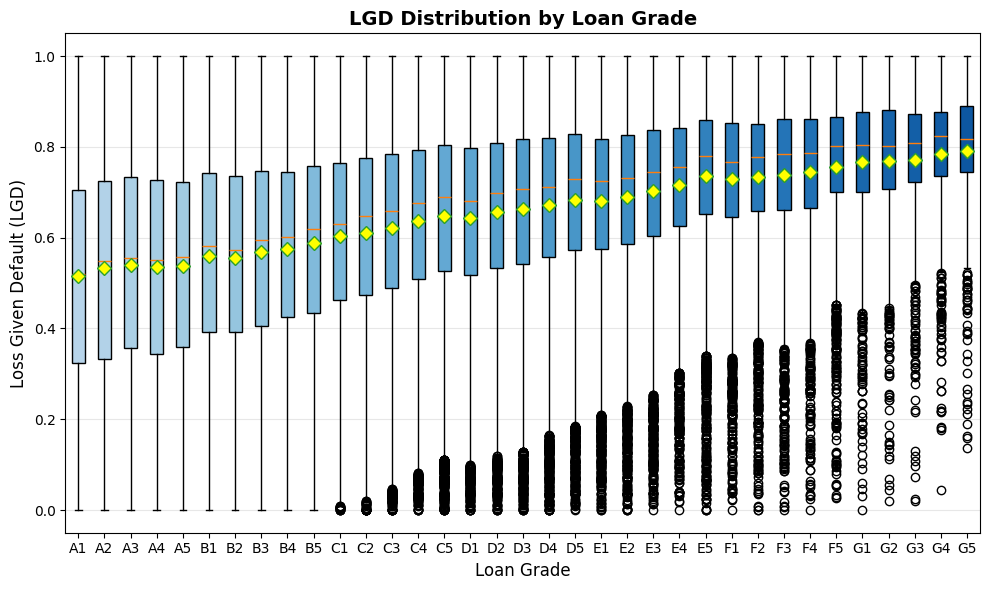

In [16]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

grade_data = [default_df[default_df['sub_grade'] == g]['lgd'].values for g in grades]
bp = ax2.boxplot(grade_data, labels=grades, patch_artist=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='yellow', markersize=7))

colors_box = plt.cm.Blues(np.linspace(0.3, 0.85, len(grades)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax2.set_xlabel('Loan Grade', fontsize=12)
ax2.set_ylabel('Loss Given Default (LGD)', fontsize=12)
ax2.set_title('LGD Distribution by Loan Grade', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lgd_distribution_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

### Compute expected profit for each borrower using PD outputs

In [17]:
# Expected revenue if borrower does not default
df_policy["expected_revenue"] = (1 - df_policy["predicted_prob"]) * df_policy["total_interest"]

# Expected loss if borrower defaults
df_policy["expected_loss"] = df_policy["predicted_prob"] * df_policy["expected_lgd"] * df_policy["loan_amnt"]

# Expected profit = expected revenue - expected loss
df_policy["expected_profit"] = df_policy["expected_revenue"] - df_policy["expected_loss"]

df_policy[
    [
        "predicted_prob",
        "total_interest",
        "expected_lgd",
        "expected_revenue",
        "expected_loss",
        "expected_profit"
    ]
].head()

,predicted_prob,total_interest,expected_lgd,expected_revenue,expected_loss,expected_profit
0,0.145790,702.40,0.655482,599.996798,243.685645,356.311153
1,0.168193,2210.11,0.621307,1838.385358,1003.193284,835.192074
2,0.103844,4236.58,0.574821,3796.638399,1253.521381,2543.117018
3,0.274075,1793.76,0.683216,1302.134949,1123.515798,178.619152
4,0.513322,11254.25,0.701859,5477.192799,7205.598633,-1728.405834


In [18]:
df_policy[
    [
        "expected_revenue",
        "expected_loss",
        "expected_profit"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
expected_revenue,391166.0,3079.213826,2810.421892,58.095548,1163.047620,2101.978877,4052.952064,28271.665843
expected_loss,391166.0,2002.509093,2251.966380,0.000000,500.912756,1142.873453,2693.802148,23324.821603
expected_profit,391166.0,1076.704734,1850.788416,-18371.339849,258.676420,738.969423,1616.227468,23665.373442
